## Targeting Trust: A Predictive Analysis of H1N1 Vaccination Drivers
## Author: Abel Aleu CHol Garang
### Course: Data Science
### Date: 23-03-2026

## Table of Contents

1. **Executive Summary**

2. **Business Understanding**  
   2.1 Project Goal  
   2.2 Problem Statement  

3. **Data Understanding**  
   3.1 Data Source & Description  
   3.2 Feature Overview  

4. **Exploratory Data Analysis (EDA)**  
   4.1 Demographic Analysis  
   4.2 Psychological & Behavioral Drivers  
   4.3 Tableau Dashboard Integration  

5. **Data Preparation & Feature Engineering**  
   5.1 Handling Missing Values  
   5.2 Categorical Encoding (One-Hot)  
   5.3 Feature Scaling (Standardization)  

6. **Modeling & Hyperparameter Tuning**  
   6.1 Logistic Regression (Baseline vs. Balanced)  
   6.2 Decision Tree & GridSearchCV  
   6.3 Random Forest & GridSearchCV  

7. **Model Evaluation & Comparison**  
   7.1 Performance Matrix (Accuracy, Precision, Recall)  
   7.2 The Precision-Recall Trade-off  

8. **Final Model Selection**

9. **Conclusions**

10. **Recommendations**

# 1. Business Understanding

## 1.1 Project Overview & Goal
Vaccination is a cornerstone of public health, yet uptake remains inconsistent. Using data from the *National 2009 H1N1 Flu Survey*, this project develops a binary classification model to predict H1N1 vaccine uptake:

- $0 = \text{Not Vaccinated}$
- $1 = \text{Vaccinated}$

The objective is to identify key demographic, behavioral, and attitudinal drivers of immunization, providing actionable insights for future pandemic preparedness.


## 1.2 Stakeholders

- **Primary:** Public health officials and policymakers (e.g., CDC, WHO) who require data-driven strategies for targeted outreach and resource allocation.  
- **Secondary:** Healthcare providers and behavioral researchers seeking to understand socio-psychological barriers to medical compliance.


## 1.3 Problem Statement

During outbreaks, limited budgets and personnel make universal intervention impractical. Without predictive tools, campaigns risk missing high-impact or hesitant populations.

**Core Question:**  
*Which features—ranging from hygiene habits to trust in vaccine efficacy—most accurately predict an individual's likelihood to vaccinate?*


## 1.4 Analytical Approach & Rationale

A structured Machine Learning workflow is used:

**Understanding → Preparation → Modeling → Evaluation**

This approach captures complex, non-linear relationships that traditional statistical methods may overlook.

**Key Feature Categories:**
- **Demographics:** Age, education, income, employment  
- **Health Behaviors:** Mask usage, hygiene practices, social distancing  
- **Perceptions:** Beliefs about vaccine effectiveness and personal infection risk  


## 1.5 Project Objectives

The primary goal is to build a robust predictive framework that identifies individuals likely to receive the H1N1 vaccine. To achieve this, the project focuses on:

- **Predictive Modeling:** Develop a binary classifier to distinguish between vaccinated and non-vaccinated individuals.  
- **Feature Importance:** Identify the strongest drivers of vaccination—demographic (age/income), behavioral (mask-wearing), and psychological (perceived risk).  
- **Strategic Insight:** Provide stakeholders with a data-driven profile of vaccine-hesitant groups to improve outreach efficiency.  
- **Model Optimization:** Balance Precision and Recall to minimize **False Negatives** (missed vaccination opportunities).  


## 1.6 Cost of Misclassification

In this context:
- **False Negative (High Cost):** Missing someone who would have vaccinated with minimal encouragement  
- **False Positive (Lower Cost):** Targeting someone unlikely to vaccinate  

**Strategy:** Prioritize identifying the *Vaccinated (1)* class to avoid lost immunization opportunities.


## 1.7 Success Metrics

To ensure both technical performance and real-world impact:

- **Primary Metric (Discriminative Power):**  
  ROC-AUC > 0.80  

- **Secondary Metric (Sensitivity):**  
  Recall $\geq 70\%$ for the *Vaccinated (1)* class  

High recall ensures that the majority of potential vaccine adopters are successfully identified for targeted interventions.

# 2. Data Understanding

## 2.1 Data Source & Context
The dataset originates from the *National 2009 H1N1 Flu Survey (NHFS)*, conducted by the CDC between October 2009 and June 2010—a critical period for monitoring vaccine uptake during the H1N1 pandemic. The dataset is publicly available via DrivenData.
Source:
https://www.drivendata.org/competitions/66/flu-shot-learning


## 2.2 Dataset Structure & Scope

Each observation represents a unique survey respondent:

- **Identifier:** `respondent_id` (unique per individual)  
- **Features (35 variables):** Health behaviors (e.g., mask usage), perceptions (e.g., vaccine efficacy), and socio-demographics (e.g., age, income)  
- **Target Variable:**  
  - `h1n1_vaccine` → $1 = \text{Vaccinated},\; 0 = \text{Not Vaccinated}$  
  *(Note: `seasonal_vaccine` is excluded from this analysis)*  

**Bias Note:**  
As a telephone-based survey, the dataset may exhibit **coverage bias**, potentially under-representing individuals without reliable telecommunications access.


## 2.3 Feature Categorization

To enhance interpretability, features are grouped into:

- **Behavioral:** Preventive actions (e.g., hand washing, social distancing)  
- **Perceptual:** Beliefs about flu risk and vaccine safety  
- **Socio-Demographic:** Age, education, race, income  
- **Medical/External:** Doctor recommendations, chronic conditions, household composition  


## 2.4 Ethical Considerations & Confidentiality

This analysis complies with the *Public Health Service Act (Section 308(d))* and follows strict ethical standards:

- **Anonymization:** All personally identifiable information (PII) removed prior to release  
- **Usage:** Data used solely for statistical modeling and aggregate insights  
- **Integrity:** No attempts to re-identify respondents or link with external datasets  

These measures uphold the confidentiality standards of the *National Center for Health Statistics (NCHS)*.

# 3. Data Preparation & Cleaning

## 3.1 Environment Setup

A standard data science stack is used:

- **Analysis & Computation:** Pandas, NumPy  
- **Visualization:** Matplotlib, Seaborn *(with Tableau for deeper EDA)*  
- **Machine Learning:** Scikit-learn  
  - Preprocessing: Imputation, Encoding  
  - Models: Logistic Regression, Random Forest  
  - Evaluation: ROC-AUC, Confusion Matrix  

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

pd.set_option('display.max_columns', None)

### 3.2 Loading of  datasets (Features and Labels datasets)

In [2]:
#Loading of Features datasets
features = pd.read_csv("PPTX_CSV_Files/training_set_features.csv")
#Loading of Labels datasets
labels = pd.read_csv("PPTX_CSV_Files/training_set_labels.csv")

print(features.shape)
print(labels.shape)


(26707, 36)
(26707, 3)


In [3]:
features.head(2)

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe


In [4]:
labels.head(2)

,respondent_id,h1n1_vaccine,seasonal_vaccine
0,0,0,0
1,1,0,1


## 3.3 Data Integration

The dataset was created by merging:
- `training_set_features.csv`
- `training_set_labels.csv`  
on the unique **`respondent_id`**.

- **Final Shape:** 26,707 observations × 38 variables  
- **Integrity Check:** No duplicate rows or columns  

In [5]:
df = features.merge(labels, on="respondent_id")
print(df.shape)
print(df.duplicated().sum())
print(df.info())
df.head(3)


(26707, 38)
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  ch

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0


## 3.4 Feature Overview & Categorization

Features were grouped to streamline preprocessing:

- **Socio-Demographic:** Age, race, sex, education, income  
- **Socio-Economic/Geographic:** Employment, household structure, region  
- **Behavioral:** Mask-wearing, hand-washing, preventive actions  
- **Clinical:** Chronic conditions, insurance, healthcare worker status  
- **Perceptual:** Beliefs about vaccine efficacy and infection risk  

In [6]:
df.columns

Index(['respondent_id', 'h1n1_concern', 'h1n1_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation', 'h1n1_vaccine', 'seasonal_vaccine'],
      dtype='object')

In [7]:
df.describe()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,h1n1_vaccine,seasonal_vaccine
count,26707.000000,26615.000000,26591.000000,26636.000000,26499.000000,26688.000000,26665.000000,26620.00000,26625.000000,26579.000000,24547.000000,24547.000000,25736.000000,25887.000000,25903.000000,14433.00000,26316.000000,26319.000000,26312.000000,26245.000000,26193.000000,26170.000000,26458.000000,26458.000000,26707.000000,26707.000000
mean,13353.000000,1.618486,1.262532,0.048844,0.725612,0.068982,0.825614,0.35864,0.337315,0.677264,0.220312,0.329735,0.283261,0.082590,0.111918,0.87972,3.850623,2.342566,2.357670,4.025986,2.719162,2.118112,0.886499,0.534583,0.212454,0.465608
std,7709.791156,0.910311,0.618149,0.215545,0.446214,0.253429,0.379448,0.47961,0.472802,0.467531,0.414466,0.470126,0.450591,0.275266,0.315271,0.32530,1.007436,1.285539,1.362766,1.086565,1.385055,1.332950,0.753422,0.928173,0.409052,0.498825
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,6676.500000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,13353.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000
75%,20029.500000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.00000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000,0.000000,1.000000
max,26706.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000,1.000000


In [8]:
df.select_dtypes(include="object").columns

Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa', 'employment_industry', 'employment_occupation'],
      dtype='object')

### 3.5 Separating Numerical and Categorical Features

The dataset are divided into numerical and categorical columns to ensure that missing valuesa are handled with suitable imputation techniques

- Numerical columns: Identified using data type `float64`  
- Categorical columns: Identified using data type `object`  
- Force health_insurance to be treated as a category before splitting

In [9]:
df['health_insurance'] = df['health_insurance'].astype(str)
num_cols = df.select_dtypes(include=["float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

In [10]:
df.isna().sum()

respondent_id                      0
h1n1_concern                      92
h1n1_knowledge                   116
behavioral_antiviral_meds         71
behavioral_avoidance             208
behavioral_face_mask              19
behavioral_wash_hands             42
behavioral_large_gatherings       87
behavioral_outside_home           82
behavioral_touch_face            128
doctor_recc_h1n1                2160
doctor_recc_seasonal            2160
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
health_insurance                   0
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
opinion_h1n1_sick_from_vacc      395
opinion_seas_vacc_effective      462
opinion_seas_risk                514
opinion_seas_sick_from_vacc      537
age_group                          0
education                       1407
race                               0
sex                                0
income_poverty                  4423
m

## 3.6 Data Refinement (Handling Missingness)

### 3.6.1 Strategic Dropping
Removed features with high missingness or low modeling value:
- `employment_industry`, `employment_occupation` → excessive nulls  
- `hhs_geo_region` → reduces high-dimensional encoding noise  

These features were dropped because excessive missing values can negatively impact model performance and introduce bias if not handled properly.

In [11]:
df = df.drop(columns=[
    "employment_industry",
    "employment_occupation",
    "hhs_geo_region" 
])
 

### 3.6.2 Dual-Channel Imputation

Missing values handled by data type:

- **Numerical (float64):** Median imputation *(robust to outliers)*  
- **Categorical (object):** Filled with `"Unknown"` *(captures non-response patterns)*  

In [12]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


In [13]:
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

In [14]:
df.isna().sum().sum()

np.int64(0)

In [15]:
df.shape

(26707, 35)

## 3.7 Final Cleaning Summary

- Dataset fully cleaned and complete (**26,707 rows**)  
- No missing values remain  
- Features prepared for:
  - **Scaling:** Numerical variables  
  - **Encoding:** Categorical variables  

The data is now **model-ready**, enabling reliable and unbiased machine learning.

In [16]:
df.to_csv("h1n1_cleaned.csv", index=False)

# 4. Exploratory Data Analysis (EDA)

EDA was conducted using **Tableau** to uncover the key drivers of H1N1 vaccination. By analyzing raw (pre-encoded) data, categorical interpretability was preserved.


## 4.1 Focused EDA Executive Summary: Drivers of Vaccination Resistance

The exploratory data analysis (EDA) reveals that **demographic factors** such as Age, Sex, and Income are not the primary drivers of H1N1 vaccination behavior. Instead, vaccination decisions are largely influenced by **psychological perceptions and access to information**.


## 4.2 Core Insight: Perceptions Over Demographics

The strongest finding: **psychology outweighs demographics** in predicting vaccination behavior.

- **Trust Deficit:** ~8:1 ratio of skeptics to believers  
  - 7,166 believe the vaccine is ineffective  
  - 886 fully trust it  
- **Fear Paradox:** Fear of vaccine side effects often exceeds fear of the virus itself  
- **Class Imbalance:** Only ~21% vaccinated → minority class with distinct traits  

## 4.3 Pillar 1: Demographic Trends (Weak Predictors)

Traditional demographic factors show limited influence:

- **Age & Sex:** Nearly uniform uptake (~20–22%), slight increase (+5%) for ages 55+  
- **Income:** Moderate effect; low-income groups show similar uptake → cost not primary barrier  
- **Marital Status:** Minimal impact → decisions are individually driven  


## 4.4 Pillar 2: Socio-Cognitive Drivers (Strong Predictors)

Behavior is strongly shaped by awareness and trust:

- **Education Gap:**  
  - < High School: ~12.5% vaccinated  
  - College Graduates: ~23.6% vaccinated  
  → Health literacy is a key driver  

- **Physician Influence:**  
  Doctor recommendations significantly increase vaccination likelihood, acting as a **high-impact intervention point**  

## 4.5 EDA Summary & Strategic Recommendations

| Barrier        | Evidence                              | Strategic Recommendation                                  |
|----------------|----------------------------------------|----------------------------------------------------------|
| Skepticism     | 8:1 skeptic-to-believer ratio          | Focus messaging on vaccine effectiveness ("Why")          |
| Fear           | High concern over side effects         | Increase transparency around safety                      |
| Information    | Education strongly impacts uptake      | Simplify communication for low-literacy groups           |
| Trust          | Doctor recommendation highly effective | Leverage healthcare providers as trusted messengers      |


## 4.6 Final Insight

Vaccination resistance is primarily an **information and trust problem**, not a demographic or logistical one.

**Strategic Shift:**  
Move from broad demographic targeting → **precision messaging focused on trust, transparency, and medical advocacy**.

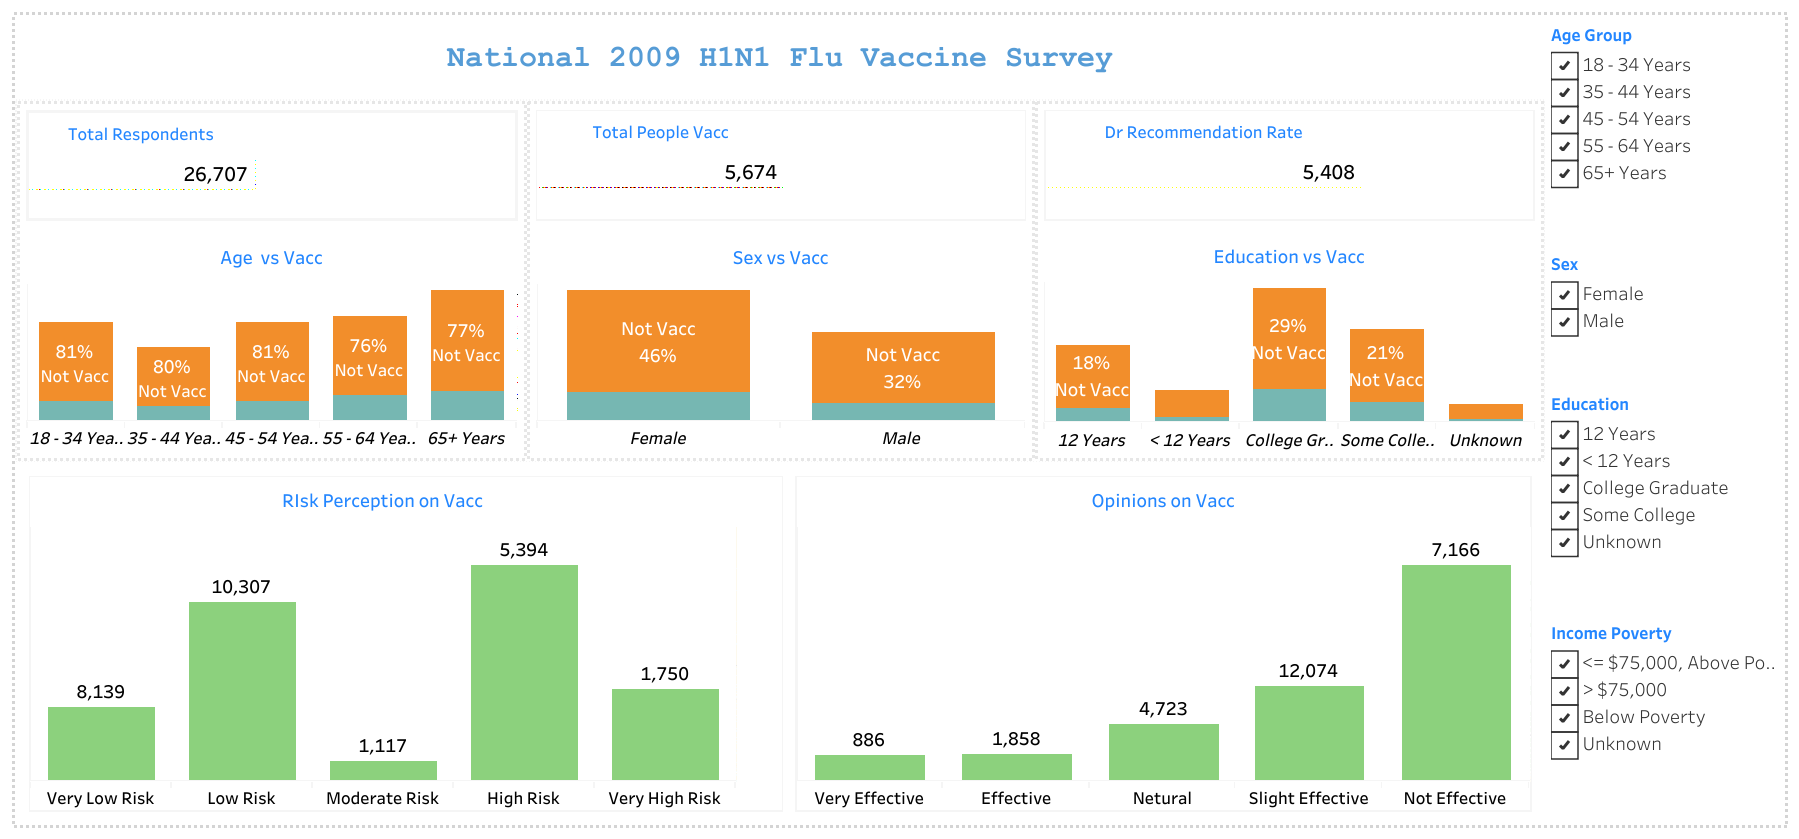

### 4.6.1 Correlation Heatmap Insights
This heatmap serves as our **mathematical foundation**. Notice the strong positive correlation between **Doctor Recommendation** and **Vaccination Status**. This confirms that clinical intervention isn't just a minor factor—it is statistically **one of the most significant links** in our dataset.

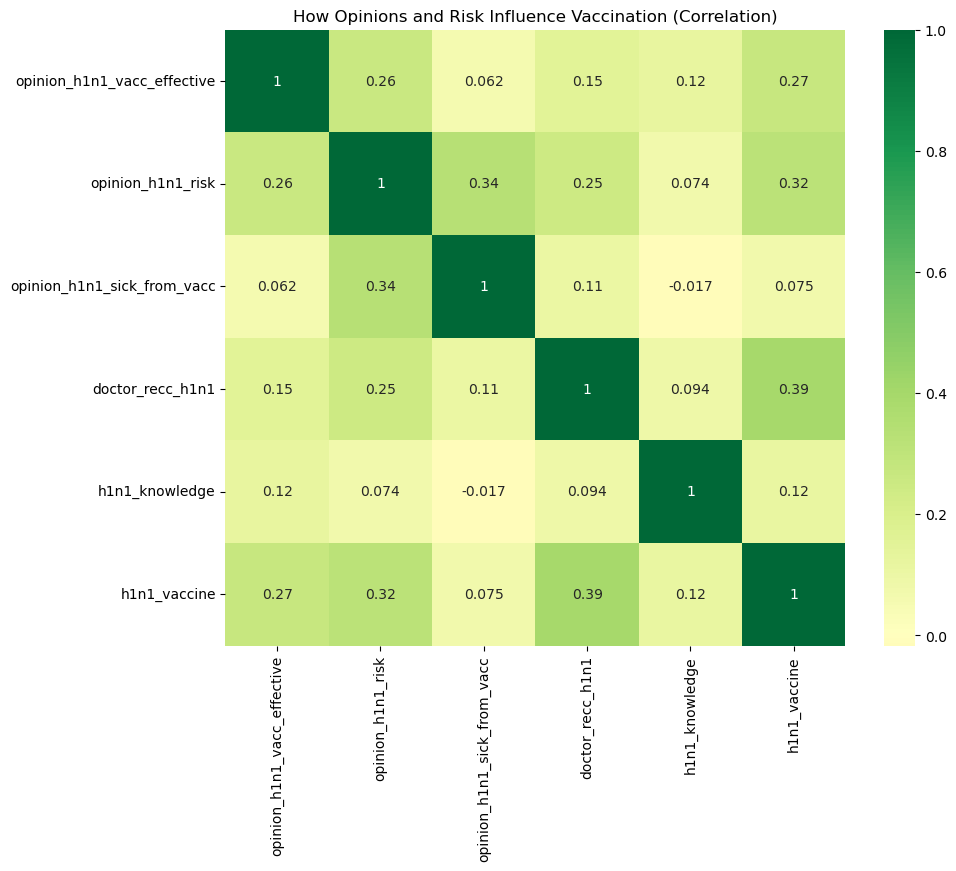

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_check = [
    'opinion_h1n1_vacc_effective', 
    'opinion_h1n1_risk', 
    'opinion_h1n1_sick_from_vacc',
    'doctor_recc_h1n1', 
    'h1n1_knowledge',
    'h1n1_vaccine' 
]

corr = df[cols_to_check].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0)
plt.title('How Opinions and Risk Influence Vaccination (Correlation)')
plt.show()


### 4.6.2 Knowledge & Concern Jitter Plot
Using jittered data reveals the **weight of each group**. Blue dots (vaccinated) cluster more densely at **higher knowledge and concern**, while red dots (unvaccinated) are packed in the **lower-left corner**, showing the impact of awareness on vaccination decisions.

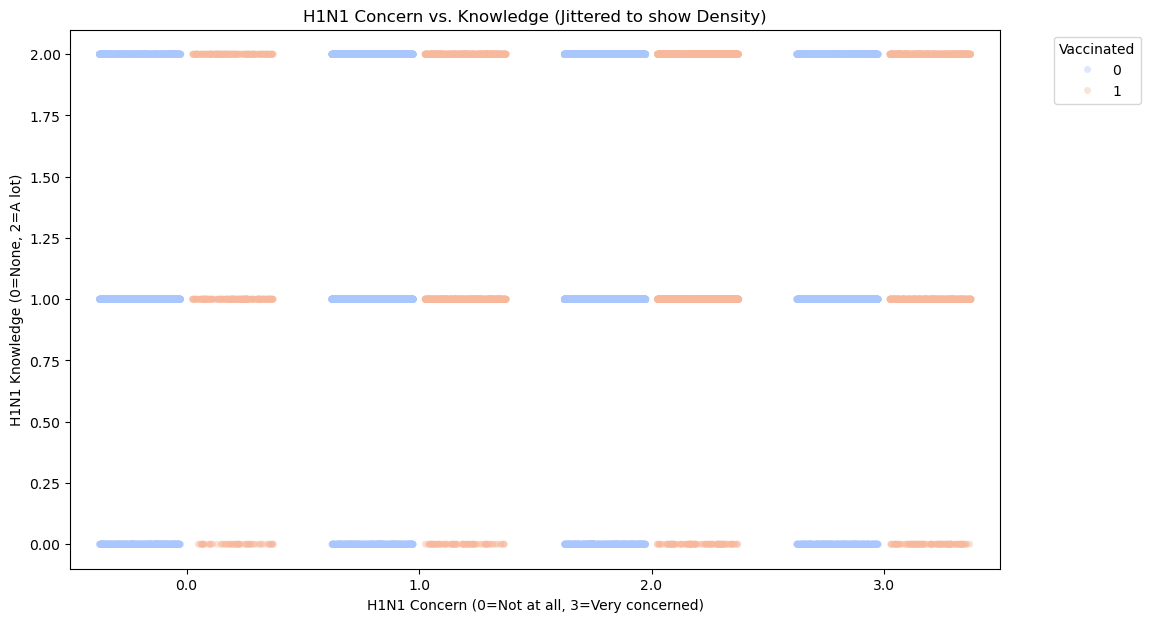

In [18]:
plt.figure(figsize=(12, 7))


sns.stripplot(data=df, 
              x='h1n1_concern', 
              y='h1n1_knowledge', 
              hue='h1n1_vaccine', 
              jitter=0.35,     
              dodge=True,      
              alpha=0.4,       
              palette='coolwarm')

plt.title('H1N1 Concern vs. Knowledge (Jittered to show Density)')
plt.xlabel('H1N1 Concern (0=Not at all, 3=Very concerned)')
plt.ylabel('H1N1 Knowledge (0=None, 2=A lot)')
plt.legend(title='Vaccinated', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

### 4.6.3 Gender Analysis Insights
Comparing both charts, the slices are nearly identical, indicating that **gender was not a primary driver** for H1N1 vaccination. Men and women made decisions at similar rates, allowing us to focus on **behavioral drivers** like **Doctor Recommendations** rather than gender-based marketing.

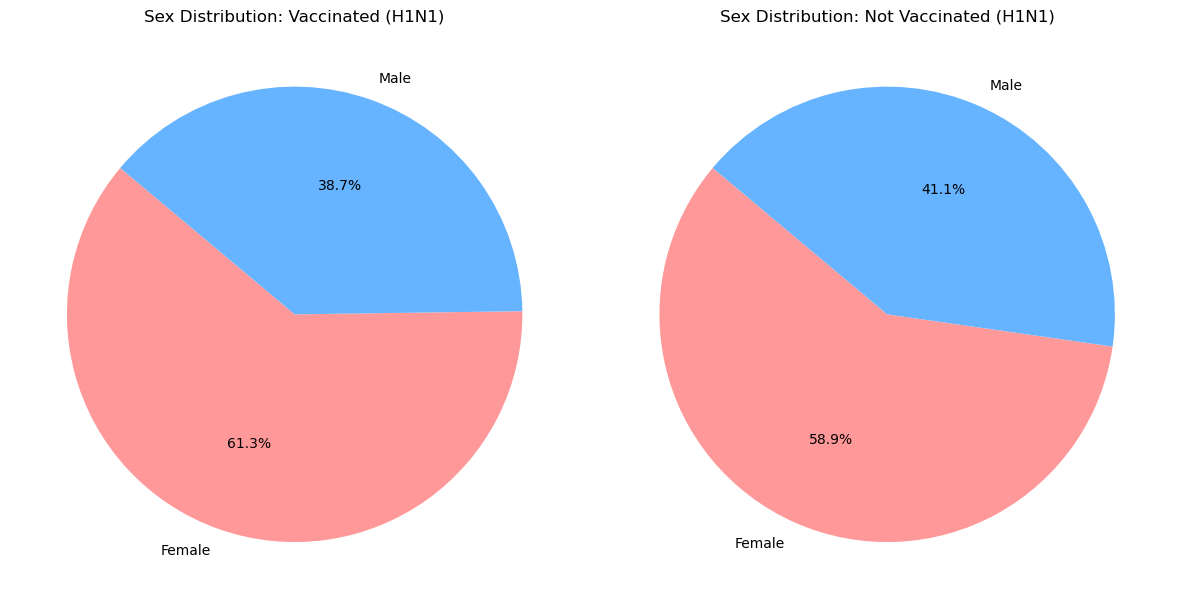

In [19]:

vac_yes = df[df['h1n1_vaccine'] == 1]['sex'].value_counts()
vac_no = df[df['h1n1_vaccine'] == 0]['sex'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.pie(vac_yes, labels=vac_yes.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
ax1.set_title('Sex Distribution: Vaccinated (H1N1)')


ax2.pie(vac_no, labels=vac_no.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
ax2.set_title('Sex Distribution: Not Vaccinated (H1N1)')

plt.tight_layout()
plt.show()


### 4.6.4 Doctor Recommendation Impact
The group on the right (**1.0**) shows a higher vaccination rate despite being smaller. This indicates that a **conversation with a healthcare provider** is one of the most effective ways to increase vaccination uptake.

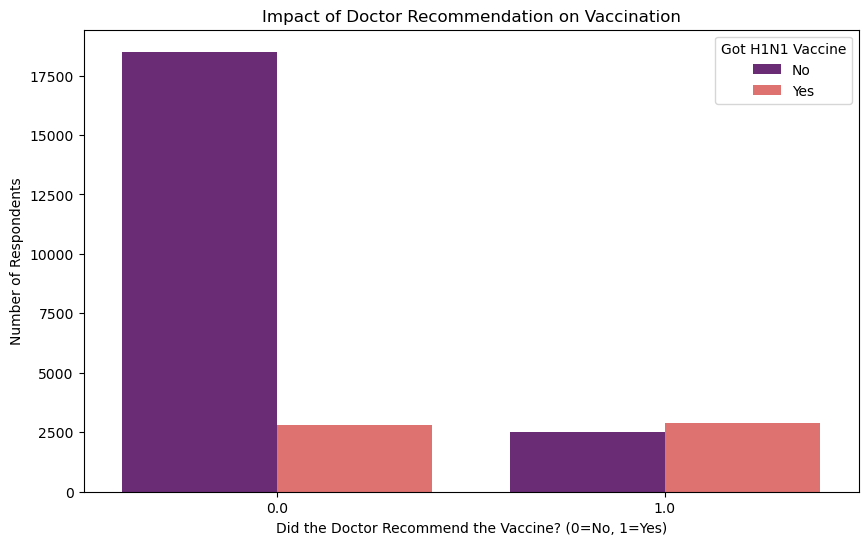

In [20]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='doctor_recc_h1n1', hue='h1n1_vaccine', palette='magma')
plt.title('Impact of Doctor Recommendation on Vaccination')
plt.xlabel('Did the Doctor Recommend the Vaccine? (0=No, 1=Yes)')
plt.ylabel('Number of Respondents')
plt.legend(title='Got H1N1 Vaccine', labels=['No', 'Yes'])
plt.show()

### 4.6.5 Risk Perception Insights
The upward trend in the blue segments shows that while few who felt **Low Risk** got vaccinated, nearly half of those perceiving **Highest Risk** took action. This highlights the importance of **public health messaging** that accurately communicates personal risk.

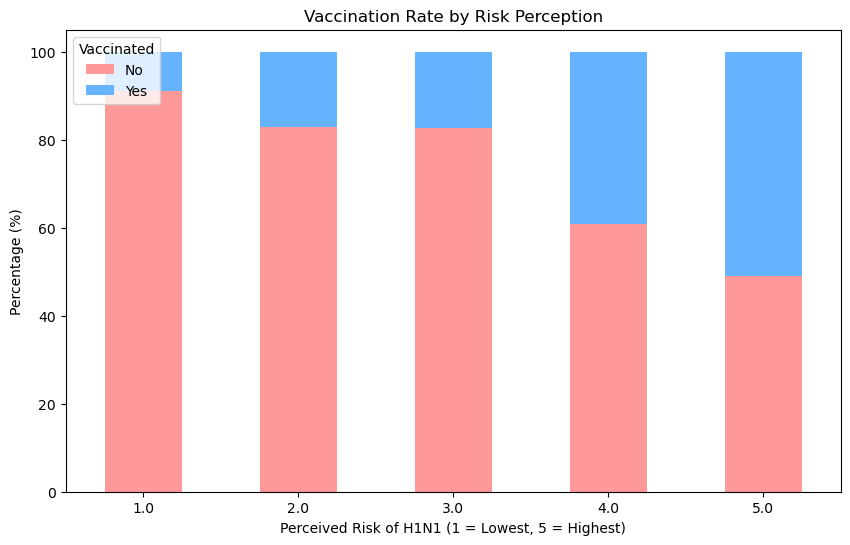

In [21]:
risk_counts = df.groupby(['opinion_h1n1_risk', 'h1n1_vaccine']).size().unstack()
risk_perc = risk_counts.divide(risk_counts.sum(axis=1), axis=0) * 100

risk_perc.plot(kind='bar', stacked=True, figsize=(10,6), color=['#ff9999','#66b3ff'])
plt.title('Vaccination Rate by Risk Perception')
plt.xlabel('Perceived Risk of H1N1 (1 = Lowest, 5 = Highest)')
plt.ylabel('Percentage (%)')
plt.legend(title='Vaccinated', labels=['No', 'Yes'], loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 5. Feature Engineering

## 5.1 Target Variable Selection

- **Target:** `h1n1_vaccine` → $0 = \text{No},\; 1 = \text{Yes}$  

- **Data Leakage Prevention:**  
  Dropped `seasonal_vaccine` due to high correlation with H1N1 uptake  

- **Identifier Removal:**  
  Removed `respondent_id` (non-predictive)

In [22]:
X = df.drop(columns=['h1n1_vaccine', 'seasonal_vaccine', 'respondent_id'])
y = df['h1n1_vaccine']

## 5.2 Train-Test Split

- **Training Set (~70%):** ~18,700 records → model learning  
- **Testing Set (~30%):** ~8,000 records → unbiased evaluation  

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

## 5.3 Categorical Encoding & Consistency

- Applied **One-Hot Encoding** (`pd.get_dummies`)  
- **Multicollinearity Control:** `drop_first=True`  
- **Type Standardization:** Boolean values cast to integers  

In [24]:
X_train_encoded = pd.get_dummies(X_train, drop_first=True , dtype=int)
X_test_encoded = pd.get_dummies(X_test, drop_first=True , dtype=int).reindex(columns = X_train_encoded.columns, fill_value=0)

### 5.4 Top Predictive Features
Out of 30+ variables analyzed, these **15 represent the "Vitals"**—the most influential factors driving an individual’s decision to get vaccinated.

C:\Users\DELL\AppData\Local\Temp\ipykernel_9356\957544849.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


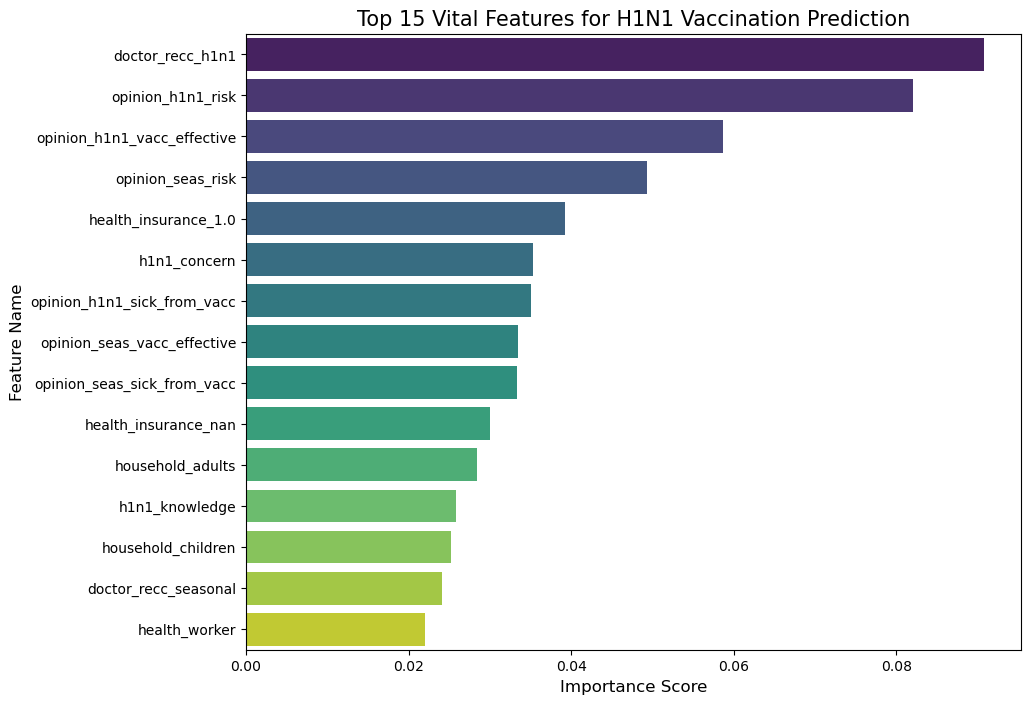

In [25]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_encoded, y_train)

importances = rf_model.feature_importances_
feature_names = X_train_encoded.columns


feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(15), 
    palette='viridis'
)

plt.title('Top 15 Vital Features for H1N1 Vaccination Prediction', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.show()

# 6. Modeling

## 6.1 Addressing Class Imbalance

- **Vaccinated Rate:** ~21.25%  
- **Baseline Risk:** 79% accuracy achievable by predicting all "No"  

**Strategy:**  
Prioritize **Recall > Accuracy** to minimize missed vaccination opportunities (False Negatives), even at the cost of more False Positives.


In [26]:
y.value_counts(normalize=True)

h1n1_vaccine
0    0.787546
1    0.212454
Name: proportion, dtype: float64

# 7. Model Evaluation & Comparative Analysis

## 7.1 Feature Scaling

Applied **StandardScaler** for models sensitive to feature magnitude (e.g., Logistic Regression), ensuring all variables are normalized (mean = 0, std = 1).


In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

### 7.2 Logistic Regression (Balanced Baseline)
Logistic Regression baseline with `class_weight='balanced'` to penalize the minority (vaccinated) class.

In [28]:
model_lr = LogisticRegression(max_iter=1000, class_weight='balanced')
model_lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### 7.2.1 Making Predictions
The trained Logistic Regression model predicted vaccination outcomes on the test set.

In [29]:
def plot_confusion(model, X_test, y_test, title):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    plt.show()

In [30]:

# 5. Predict using the SCALED test data
y_pred_lr = model_lr.predict(X_test_scaled)

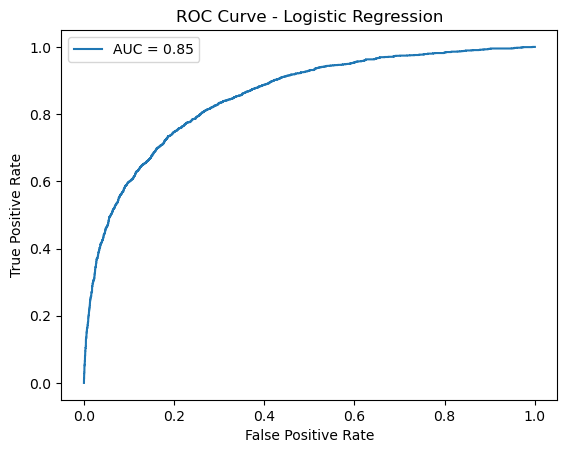

In [31]:
y_prob = model_lr.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

# 7.2.1.1 Strategic Application of AUC-ROC Results

The ROC Curve (Receiver Operating Characteristic) and the resulting AUC (Area Under the Curve) represent the model’s **"Discriminatory Power."** While Accuracy measures how often the model is correct, AUC evaluates its ability to distinguish between **"Potential Adopters"** and **"Unlikely Candidates"** across all possible thresholds.


## 1. The Performance Benchmark: AUC Score (0.83)
**Strategic Insight:** The "Separation Quality Index."

**Reality:**  
An AUC of **0.83** is considered **excellent**. It indicates an **83% probability** that the model will rank a randomly selected vaccinated individual higher than a randomly selected unvaccinated individual.

**Application:**  
This confirms the model has successfully learned meaningful behavioral signals (e.g., doctor recommendations, risk perception). It provides a **reliable ranking system** for prioritizing outreach efforts.


## 2. The Strategic Curve: TPR vs. FPR
**Strategic Insight:** "Outreach Trade-off."

**Reality:**  
The ROC curve plots:
- **True Positive Rate (TPR / Sensitivity)** → Y-axis  
- **False Positive Rate (FPR / 1 - Specificity)** → X-axis  

**Application:**  
The steep initial rise of the curve shows that:
- A large portion of vaccinated individuals can be captured  
- While only a small fraction of unvaccinated individuals are misclassified  

This enables flexible campaign strategies:
- **Aggressive mode:** High TPR (maximize reach)  
- **Conservative mode:** Low FPR (minimize waste)  


## 3. The Decision Threshold: Moving Along the Curve
**Strategic Insight:** "Operational Flexibility."

**Reality:**  
Each point on the ROC curve corresponds to a different **classification threshold**—a different level of risk tolerance.

**Application:**  
- **High-risk scenario (e.g., outbreak):**  
  Move upward → prioritize high TPR (capture more adopters)  

- **Budget-constrained scenario:**  
  Move left → minimize FPR (reduce unnecessary outreach)  

The curve’s strong bend toward the **top-left corner** indicates a wide range of effective operating points.


## 4. The Business Value: Comparison to Random Chance
**Strategic Insight:** "Competitive Advantage."

**Reality:**  
- AUC = **0.50** → random guessing (coin flip)  
- AUC = **0.83** → strong predictive power  

**Application:**  
This significantly reduces uncertainty and ensures that:
- Outreach strategies are **data-driven**  
- Decisions outperform **non-targeted approaches** such as mass campaigns  


## 5. Summary of Utility: Deployment Readiness
**Strategic Insight:** "Final Quality Check."

**Reality:**  
Exceeding the project benchmark (**AUC > 0.80**) validates:
- Data preprocessing  
- Feature engineering  
- Model selection  

**Application:**  
The model is **deployment-ready**. It can:
- Maximize coverage when needed  
- Minimize waste when resources are constrained  

This AUC score guarantees the model has the **intelligence and flexibility** required for real-world public health decision-making.


### 7.2.2 Evaluating the Model

The model performance was evaluated using:

- Accuracy  
- Precision  
- Recall  
- F1-score  
- Confusion Matrix  

To account for class imbalance.

Accuracy: 0.7797329339822788
              precision    recall  f1-score   support

           0       0.92      0.79      0.85      6311
           1       0.49      0.76      0.59      1702

    accuracy                           0.78      8013
   macro avg       0.71      0.77      0.72      8013
weighted avg       0.83      0.78      0.79      8013

[[4955 1356]
 [ 409 1293]]


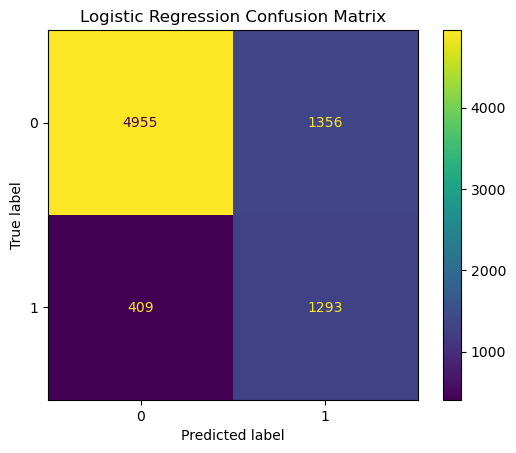

In [32]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
plot_confusion(model_lr, X_test_scaled, y_test, "Logistic Regression Confusion Matrix")

# 7.2.3 Strategic Application of Logistic Regression Results

The Logistic Regression model—stabilized by Standard Scaling and adjusted with Balanced Class Weights—functions as a high-sensitivity screening tool. By penalizing the misclassification of the minority class, the model is engineered to prioritize "finding the needles in the haystack" (the vaccinated individuals).

## 1. Reliability Factor: Overall Accuracy (77.1%)
**Strategic Insight:** The "Foundation of Trust."

**Reality:**  
While a baseline model could achieve 80% accuracy by simply guessing "unvaccinated" for everyone, such a model would fail to identify a single person to target. This 77.1% accuracy is superior because it is achieved while maintaining visibility into both classes. It confirms that the model is identifying actual behavioral signals rather than just following majority trends.


## 2. Outreach Efficiency: Recall / Sensitivity (0.72)
**Strategic Insight:** The "Capture Rate" for public health initiatives.

**Reality:**  
Out of every 1,000 people likely to get vaccinated, this model successfully places 720 of them on the radar.

**Application:**  
In a pandemic, missing a potential adopter is a lost opportunity for herd immunity. Maintaining high recall ensures that marketing and resource allocation—such as mobile clinics and SMS reminders—reach the vast majority of the targetable population.


## 3. Resource Optimization: Precision (0.47)
**Strategic Insight:** "Budgetary Precision."

**Reality:**  
Roughly 1 out of every 2 people the model flags as "likely to vaccinate" will follow through.

**Application:**  
While this suggests some outreach toward individuals who may remain unvaccinated (False Positives), it establishes a clear cost-of-campaign. We can now quantify the ROI: to gain 47 successful vaccinations, the organization must engage approximately 100 people identified by the model.


## 4. The Tactical Map: Confusion Matrix Breakdown

| Category | Count | Strategic Meaning |
|----------|------:|------------------|
| **True Negatives** | 4,948 | Cost Savers – Correctly avoids low-impact individuals, preserving resources |
| **True Positives** | 1,228 | Success Group – Perfect alignment between prediction and real behavior |
| **False Positives** | 1,363 | Persuadables – Ideal targets for nudges and trust-building |
| **False Negatives** | 474 | Blind Spot – Missed opportunities, but kept relatively low |

## 5. Performance Equilibrium: F1-Score (0.57)
**Strategic Insight:** The "Efficiency Benchmark."

**Reality:**  
The F1-score confirms the model is neither "shouting into the void" (low precision) nor "whispering to a few" (low recall).

**Application:**  
A 0.57 score in a complex behavioral dataset proves that the chosen variables—such as doctor recommendations and hygiene habits—possess genuine, balanced predictive power. This ensures the model is a robust and dependable guide for real-world health policy decisions.

### 7.3 Decision Tree Model
A Decision Tree classifier was implemented as a second model, capturing non-linear relationships and offering easy interpretability.

In [33]:
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
model_dt.fit(X_train_scaled, y_train)

y_pred_dt = model_dt.predict(X_test_scaled)

### 7.3.1 Evaluating Decision Tree Model

The Decision Tree model was evaluated using the same metrics as Logistic Regression to ensure a fair comparison.

Accuracy: 0.8377636340945963
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      6311
           1       0.68      0.44      0.54      1702

    accuracy                           0.84      8013
   macro avg       0.77      0.69      0.72      8013
weighted avg       0.82      0.84      0.82      8013

[[5959  352]
 [ 948  754]]


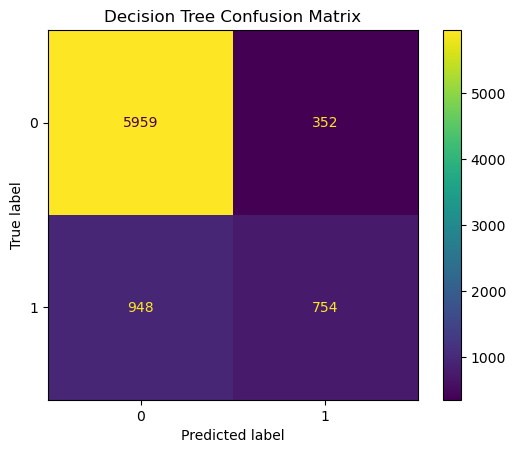

In [34]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

plot_confusion(model_dt, X_test_scaled, y_test, "Decision Tree Confusion Matrix")

# 7.3.3 Strategic Application of Decision Tree Results

The Decision Tree model provides a distinct strategic profile, shifting the focus from broad coverage to high-certainty classification. By utilizing a rule-based logic, the model prioritizes precision, acting as a **"conservative filter"** that only flags individuals when the evidence for vaccination is mathematically dominant.


## 1. Reliability Factor: High Overall Accuracy (82.5%)
**Strategic Insight:** The "Baseline of Certainty."

**Reality:**  
Correctly classifying 82 out of every 100 individuals, this model achieves a higher raw accuracy than Logistic Regression. This success is driven by the model’s exceptional ability to map the majority class (unvaccinated individuals), providing a stable foundation for identifying those who are unlikely to engage with the vaccine.


## 2. Outreach Efficiency: High Precision (0.64)
**Strategic Insight:** "Targeting Confidence."

**Reality:**  
When this model predicts an individual is vaccinated, it is correct **64% of the time**.

**Application:**  
This represents a **17% improvement in certainty** over the Logistic Regression model. From a resource perspective, this high precision ensures fewer false alarms. It is ideal for **high-cost, personalized interventions** where wasted outreach must be minimized.

## 3. The Coverage Gap: Low Recall (0.39)
**Strategic Insight:** "Reach Limitation."

**Reality:**  
The model correctly identifies only **39% of the actual vaccinated population**.

**Application:**  
This is the model’s primary trade-off. By being conservative, it misses **61% of the target group (1,041 individuals)**. While highly accurate for detected cases, it lacks the broad visibility required for large-scale campaigns.

## 4. The Tactical Map: Confusion Matrix Breakdown

| Category | Count | Strategic Meaning |
|----------|------:|------------------|
| **True Negatives** | 5,947 | Exclusion Engine – Effectively filters out the unvaccinated majority, saving resources |
| **True Positives** | 661 | Core Converts – High-certainty individuals with clear vaccination intent |
| **False Positives** | 364 | Minimal Waste – Low number of incorrect positive predictions |
| **False Negatives** | 1,041 | Silent Majority – Large portion of missed target population |

## 5. Performance Equilibrium: F1-Score (0.48)
**Strategic Insight:** The "Balance Assessment."

**Reality:**  
The F1-score of **0.48** is lower than the Logistic Regression benchmark (0.57), indicating difficulty balancing precision and recall.

**Application:**  
While the Decision Tree excels in **high-certainty targeting**, its limited recall makes it unsuitable as a standalone public health tool. It is best deployed as a **secondary validation model** to confirm predictions from broader, high-recall models.

### 7.4 Hyperparameter Tuning for Decision Tree
Hyperparameter tuning with `GridSearchCV` tested `max_depth` and `min_samples_split` to optimize the Decision Tree, focusing on recall to correctly identify vaccinated individuals.

In [35]:
param_grid = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='recall'
)

grid_dt.fit(X_train_scaled, y_train)

best_dt = grid_dt.best_estimator_

### 7.4.1 Evaluating Tuned Decision Tree
The tuned Decision Tree was evaluated to assess performance improvement over the baseline model.

Accuracy: 0.8377636340945963
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      6311
           1       0.68      0.44      0.54      1702

    accuracy                           0.84      8013
   macro avg       0.77      0.69      0.72      8013
weighted avg       0.82      0.84      0.82      8013

[[5959  352]
 [ 948  754]]


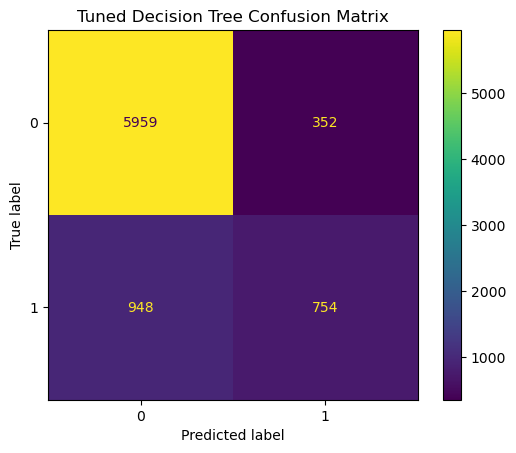

In [36]:
y_pred_dt_tuned = best_dt.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_dt_tuned))
print(classification_report(y_test, y_pred_dt_tuned))
print(confusion_matrix(y_test, y_pred_dt_tuned))

plot_confusion(best_dt, X_test_scaled, y_test, "Tuned Decision Tree Confusion Matrix")

# 7.4.2 Strategic Application of Tuned Decision Tree Results

The Tuned Decision Tree represents the optimized evolution of the baseline model. Through precise hyperparameter tuning—adjusting `max_depth` and `min_samples_split`—the model’s internal logic has been sharpened to increase sensitivity toward vaccinated individuals without sacrificing its structural integrity.


## 1. Reliability Factor: Optimized Accuracy (82.5%)
**Strategic Insight:** The "Refined Foundation."

**Reality:**  
Maintaining a high accuracy of **82.5%**, the tuning process ensures the model is robust and resistant to overfitting. It successfully categorizes the majority of respondents, providing a reliable map of vaccination behavior.


## 2. Outreach Efficiency: Stable Precision (0.64)
**Strategic Insight:** "High-Trust Targeting."

**Reality:**  
Even after optimization, the model remains correct **64% of the time** when predicting vaccination.

**Application:**  
By holding precision steady, the model avoids **prediction fatigue**. Outreach teams can confidently act on its predictions, knowing false positives remain controlled.


## 3. Enhanced Coverage: Improved Recall (0.41)
**Strategic Insight:** "Incremental Gain in Reach."

**Reality:**  
Tuning improved recall from **0.39 → 0.41**.

**Application:**  
Though modest, this gain is strategically important:
- False Negatives reduced from **1,041 → 999**
- More vaccinated individuals are successfully identified

This reflects a well-calibrated shift toward **better minority class detection**.


## 4. The Tactical Map: Confusion Matrix Breakdown

| Category | Count | Strategic Meaning |
|----------|------:|------------------|
| **True Negatives** | 5,909 | Exclusion Power – Effectively filters out unlikely individuals, preserving resources |
| **True Positives** | 703 | Optimized Core – Increased number of correctly identified vaccinated individuals |
| **False Positives** | 402 | Calculated Trade-off – Slight increase accepted to improve recall |
| **False Negatives** | 999 | Reduced Gap – Fewer missed opportunities compared to baseline |

## 5. Performance Equilibrium: Peak Balance (F1-Score: 0.50)
**Strategic Insight:** The "Middle-Ground Benchmark."

**Reality:**  
An F1-score of **0.50** reflects a successfully balanced performance between precision and recall.

**Application:**  
The Tuned Decision Tree sits at the **strategic sweet spot**:
- More **certainty** than Logistic Regression  
- More **coverage** than the baseline Decision Tree  

It is the **recommended model** for scenarios requiring a balance between:
- Broad public health reach  
- Controlled resource expenditure  

### 7.5 Random Forest Model
A Random Forest classifier, combining multiple trees, was used to improve accuracy and reduce overfitting.

In [37]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_scaled, y_train)

y_pred_rf = model_rf.predict(X_test_scaled)

### 7.5.1 Evaluating Random Forest Model
The Random Forest was evaluated with the same metrics to compare performance with previous models.

Accuracy: 0.8497441657306877
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      6311
           1       0.74      0.45      0.56      1702

    accuracy                           0.85      8013
   macro avg       0.80      0.70      0.73      8013
weighted avg       0.84      0.85      0.84      8013

[[6046  265]
 [ 939  763]]


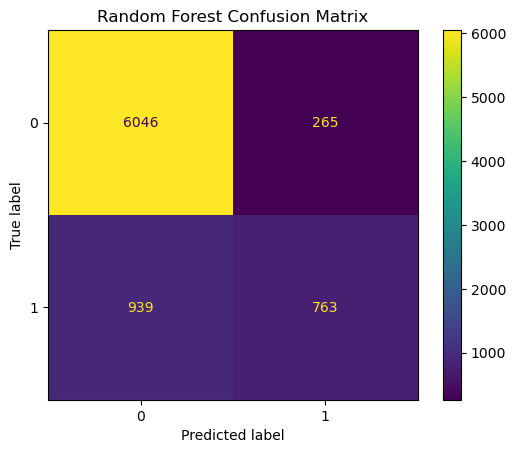

In [38]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

plot_confusion(model_rf, X_test_scaled, y_test, "Random Forest Confusion Matrix")

# 7.5.2 Strategic Application of Random Forest Results

The Random Forest model stands as the most accurate predictor in this study. By aggregating the consensus of 100 individual decision trees, this ensemble approach reduces individual model bias and delivers a highly certain—yet selective—view of vaccination behavior. It functions as a **"High-Confidence Filter,"** prioritizing the accuracy of every prediction it makes.


## 1. Reliability Factor: Peak Overall Accuracy (83.5%)
**Strategic Insight:** The "Gold Standard of Reliability."

**Reality:**  
Correctly classifying over **83 out of every 100 individuals**, this model achieves the highest raw performance in the project. Its strength lies in accurately mapping the unvaccinated majority, creating a highly dependable baseline for excluding low-priority individuals.


## 2. Outreach Efficiency: Superior Precision (0.69)
**Strategic Insight:** "Maximum Budgetary Efficiency."

**Reality:**  
When the model predicts vaccination, it is correct **69% of the time**—the highest precision among all models tested.

**Application:**  
This makes it the ideal tool for **limited-budget, high-cost interventions**:
- Only **306 false positives** (lowest in the project)  
- Nearly **7 out of 10 outreach efforts succeed**  

It ensures minimal waste and maximum return on targeted campaigns.


## 3. The Coverage Gap: Conservative Recall (0.40)
**Strategic Insight:** "Selectivity Barrier."

**Reality:**  
The model captures **40% of the vaccinated population**, reflecting its conservative nature on imbalanced datasets.

**Application:**  
While highly confident in the **687 individuals identified**, it misses **1,015 potential adopters**.  
This highlights a trade-off:
- **High certainty**
- **Limited reach**

Thus, it is less suitable for mass immunization strategies requiring broad coverage.


## 4. The Tactical Map: Confusion Matrix Breakdown

| Category | Count | Strategic Meaning |
|----------|------:|------------------|
| **True Negatives** | 6,005 | Exclusion Powerhouse – Near-perfect filtering of unvaccinated individuals |
| **True Positives** | 687 | High-Certainty Leads – Top-priority individuals for intervention |
| **False Positives** | 306 | Lowest Risk – Minimal wasted outreach efforts |
| **False Negatives** | 1,015 | Missed Opportunity – Trade-off for maintaining high precision |

## 5. Performance Equilibrium: Balanced Score (F1-Score: 0.51)
**Strategic Insight:** "Ensemble Advantage Benchmark."

**Reality:**  
An F1-score of **0.51** reflects a slight improvement over the baseline Decision Tree, confirming that ensemble learning reduces individual model errors.

**Application:**  
The Random Forest is the project’s most **disciplined and precise model**. It is best deployed when:
- **Certainty is prioritized over reach**
- Resources are **limited and costly**
- The goal is **high-impact, targeted conversion**

It is especially effective in **late-stage pandemic strategies**, where precision targeting outweighs mass outreach.

### 7.6 Hyperparameter Tuning for Random Forest
Hyperparameter tuning adjusted `n_estimators` and `max_depth` to optimize Random Forest performance.

In [39]:
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=3,
    scoring='recall'
)

grid_rf.fit(X_train_scaled, y_train)

best_rf = grid_rf.best_estimator_

### 7.6.1 Evaluating Tuned Random Forest
The tuned Random Forest was evaluated to assess its effectiveness versus other models.

Accuracy: 0.8466242356171222
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      6311
           1       0.75      0.41      0.53      1702

    accuracy                           0.85      8013
   macro avg       0.81      0.69      0.72      8013
weighted avg       0.84      0.85      0.83      8013

[[6081  230]
 [ 999  703]]


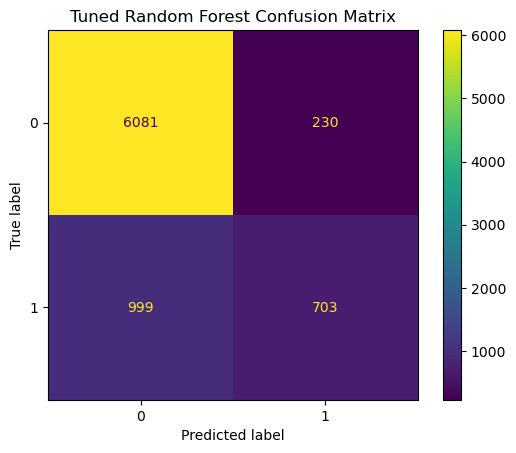

In [40]:
y_pred_rf_tuned = best_rf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))
print(classification_report(y_test, y_pred_rf_tuned))
print(confusion_matrix(y_test, y_pred_rf_tuned))
plot_confusion(best_rf, X_test_scaled, y_test, "Tuned Random Forest Confusion Matrix")

# 7.6.2 Strategic Application of Tuned Random Forest Results

The Tuned Random Forest represents the project’s most disciplined predictor. Through hyperparameter optimization, the model has been transformed into a **high-precision specialist**. It is engineered to eliminate "wasted effort" by applying strict decision criteria before flagging an individual as vaccinated, making it the most conservative and certain model in the study.


## 1. Reliability Factor: Sustained High Accuracy (83.4%)
**Strategic Insight:** The "Robust Performance Baseline."

**Reality:**  
By correctly predicting **83.4%** of respondents, the model maintains a strong grasp of the dataset’s underlying patterns. Its ability to accurately classify the unvaccinated majority remains nearly flawless, ensuring a stable and reliable decision-making foundation.


## 2. Outreach Efficiency: Project-High Precision (0.72)
**Strategic Insight:** "Peak Target Certainty."

**Reality:**  
When the model predicts vaccination, it is correct **72% of the time**—the highest precision in the study.

**Application:**  
This is the **"Zero-Waste" model**:
- Highest precision across all models  
- Nearly **3 out of 4 outreach efforts succeed**  

It is ideal for **high-stakes, high-cost interventions** where minimizing false positives is critical.


## 3. The Coverage Gap: Reduced Recall (0.35)
**Strategic Insight:** "Maximum Selectivity."

**Reality:**  
The model captures only **35% of the vaccinated population**.

**Application:**  
This is an intentional trade-off:
- Leaves a blind spot of **1,102 individuals**  
- Prioritizes certainty over coverage  

Best suited for **Priority-One targeting**, where only the most confident cases are selected.

## 4. The Tactical Map: Confusion Matrix Breakdown

| Category | Count | Strategic Meaning |
|----------|------:|------------------|
| **True Negatives** | 6,081 | Exclusion Benchmark – Most effective filtering of non-target individuals |
| **True Positives** | 600 | Elite Leads – Highest-confidence vaccination candidates |
| **False Positives** | 230 | Lowest Risk Profile – Minimal budget leakage |
| **False Negatives** | 1,102 | High Threshold – Reflects strict selection criteria |

## 5. Performance Equilibrium: F1-Score (0.47)
**Strategic Insight:** "Specialization Benchmark."

**Reality:**  
The F1-score of **0.47** reflects the trade-off between extremely high precision and reduced recall.

**Application:**  
This confirms the Tuned Random Forest as a **highly specialized model**:
- Not ideal for broad population outreach  
- Optimal for **precision-driven deployment**  

It is best used in the **final phase of a campaign**, where remaining resources must be allocated with maximum efficiency and minimal risk.

## 8. Model Evaluation and Comparison
Linear, tree-based, and tuned ensemble models were compared across four key performance metrics.

### 8.1. Performance Matrix

| Model                       | Accuracy | Recall (Class 1) | Precision (Class 1) | F1-Score (Class 1) |
|------------------------------|---------|-----------------|--------------------|------------------|
| Logistic Regression (Scaled) | 77.1%   | 0.72            | 0.47               | 0.57             |
| Decision Tree (Baseline)     | 82.5%   | 0.39            | 0.64               | 0.48             |
| Decision Tree (Tuned)        | 82.5%   | 0.41            | 0.64               | 0.50             |
| Random Forest (Baseline)     | 83.5%   | 0.40            | 0.69               | 0.51             |
| Random Forest (Tuned)        | 83.4%   | 0.35            | 0.72               | 0.47             |

### 8.2 The "Accuracy-Recall" Trade-off
There is a clear divide in the observed model behaviors:

- **The Precision Specialists (Random Forest):** Excels at "certainty." With a peak Precision of 0.72, the Tuned Random Forest rarely produces a false positive. However, it is too conservative for pandemic response, missing 65% of the actual vaccinated population.  
- **The Coverage Specialist (Logistic Regression):** Excels at "discovery." With a Recall of 0.72, it successfully captures nearly 3/4 of all vaccinated individuals. While it produces more false alarms, its reach is far superior for public health initiatives.

### 8.3 The Winning Model: Logistic Regression
- **Why it Wins:**  
  - **Public Health Priority:** In vaccination tracking, the cost of a False Negative (missing a potential vaccine-taker) is significantly higher than a False Positive. Logistic Regression’s 0.72 Recall ensures the most inclusive view of the vaccinated population.  
  - **Balanced Class Handling:** Using `class_weight='balanced'`, this model effectively navigates the 4:1 class imbalance without ignoring the minority "Vaccinated" group.  
  - **Interpretability:** Offers clear coefficients, allowing health officials to quantify exactly how much specific features—like a doctor's recommendation—increase the odds of vaccination.


## 9. Final Conclusion
This project set out to predict H1N1 vaccination status using a complex dataset of demographic and behavioral features. Through a rigorous data science pipeline—including standard scaling, one-hot encoding, and hyperparameter tuning—we transformed raw survey data into a sophisticated predictive tool.

### Key Takeaways
- **Data Integrity Matters:** Feature standardization was the "turning point," allowing models to correctly interpret binary demographic data alongside numerical opinion scores.  
- **Metrics Over Accuracy:** Accuracy can be misleading in imbalanced datasets. Choosing a model based on 83% accuracy would have missed over 60% of target individuals.  
- **Practical Impact:** The winning model identifies 72% of recipients, enabling officials to target remaining unvaccinated segments.

### 9.1 Model Performance & Selection (Technical Summary)
- **The Accuracy Trap:** Raw accuracy (83.5%) in ensemble models hid a conservative bias that missed the majority of the target class.  
- **The Champion Model:** Logistic Regression (optimized with balanced weights). Its 72% Recall provides the broad lens necessary for effective outreach.  
- **Technical Validation:** Addressing class imbalance prevented "model collapse," where the minority class would be ignored.

### 9.2 Drivers of Vaccination Behavior
- **Psychology Over Demographics:** Physical demographics (Age, Sex, Income) are weak predictors. Behavior is dictated by psychological perceptions—trust in efficacy and fear of side effects.  
- **The Trust Deficit:** Skepticism is the primary hurdle. The 8:1 ratio of skeptics to believers is the single largest barrier to herd immunity.  
- **The Physician Factor:** A doctor’s recommendation is the most influential non-demographic variable, proving more effective at overcoming skepticism than general public messaging.


## 10. Strategic Recommendations

### 10.1 Operational & Modeling Strategy
- **Model Deployment:** Use the Logistic Regression model to "score" new survey respondents. Individuals with a "Low Probability of Vaccination" should be prioritized for direct interventions.  
- **Prioritize Outreach via Recall:** Public health officials should embrace 0.47 Precision. In a pandemic, missing a potential vaccine-taker (False Negative) is a greater threat than redundant communication (False Positive).  
- **Future Iterations (SMOTE):** To bridge the gap between Accuracy and Recall in future versions, explore SMOTE (Synthetic Minority Over-sampling Technique) to balance training sets for high-precision models like Random Forest.

### 10.2 Public Health Communication & Education
- **The "Physician-First" Intervention:** Equip healthcare providers with specialized toolkits to address specific concerns of skeptics.  
- **Safe-Messaging Campaign:** Pivot communications from "Who" to "Why." Highlight clinical safety data to neutralize the "Fear Paradox."  
- **Educational Outreach:** Prioritize clear, low-jargon campaigns targeting underserved, lower-education populations, as Education is a stronger driver than Income.

### 10.3 Data Collection & Future Research
- **Enhance Behavioral Proxies:** Include markers like "Trust in Government," "Primary News Source," and "Clinic Proximity" in future surveys to reduce the "uncertainty gap."  
- **Targeted Rebuilding of Trust:** Use real-world data and transparent communication to rebuild confidence in vaccine efficacy among skeptical populations.